🌟 **Exercises XP: Data Visualization**

Use Matplotlib and Seaborn to visualize weekly temperatures, monthly sales, and student mental health survey responses.

Data: `Student Mental health.csv`. Keep this file beside the notebook and run the cells from top to bottom. Required packages: pandas, matplotlib and seaborn.

Dataset source: [Student Mental health — MD Shariful Islam, Kaggle](https://www.kaggle.com/datasets/shariful07/student-mental-health). Exercises 2 and 3 use the example values supplied in the assignment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter
from IPython.display import display


**🌟 Exercise 1: Understanding Data Visualization**

Data visualization presents information in graphs so patterns, differences, trends, and unusual values are easier to see. It helps me explore a dataset and communicate findings clearly. Labels, units, and suitable scales make the charts easier to interpret.

A line graph shows how a numerical value changes across an ordered sequence, usually time. Connecting consecutive observations helps reveal increases, decreases, and turning points. For example, a line graph can show how the temperature changes from Monday to Sunday.

**🌟 Exercise 2: Creating a Line Plot for Temperature Variation**

I use one temperature for each day of the week. Markers show the observations, and the line makes the changes between days easier to follow.

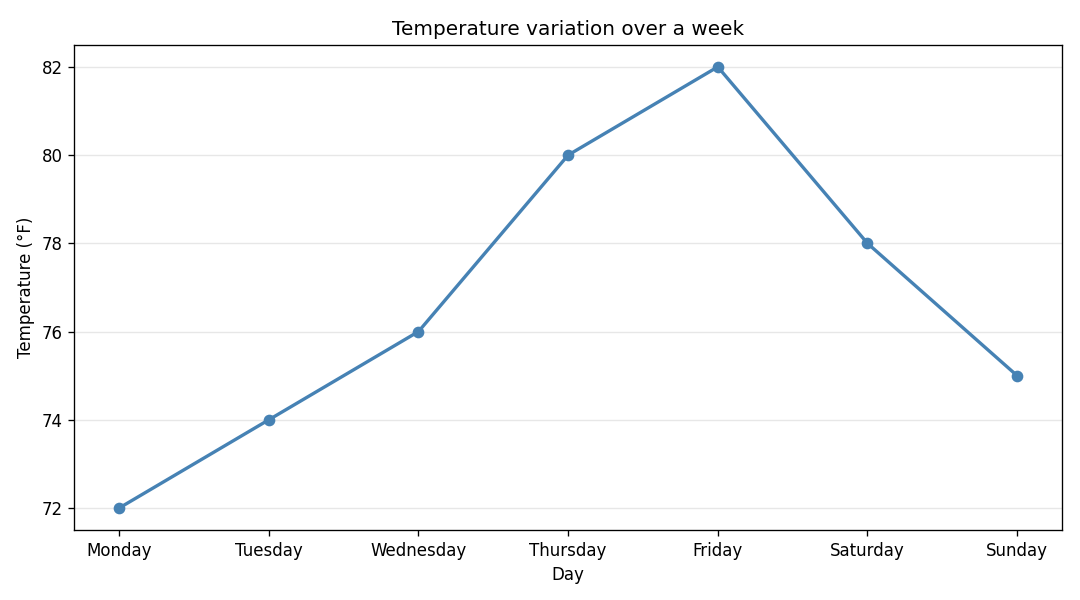

In [2]:
# Plot the example temperatures in chronological order.
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
temperatures = [72, 74, 76, 80, 82, 78, 75]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(days, temperatures, marker="o", color="steelblue", linewidth=2)

ax.set_title("Temperature variation over a week")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature (°F)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The temperature rises from 72°F on Monday to a peak of 82°F on Friday, then falls to 75°F on Sunday.

**🌟 Exercise 3: Visualizing Monthly Sales with a Bar Chart**

The example contains five sales values. I label them January through May and use a bar chart to compare the months.

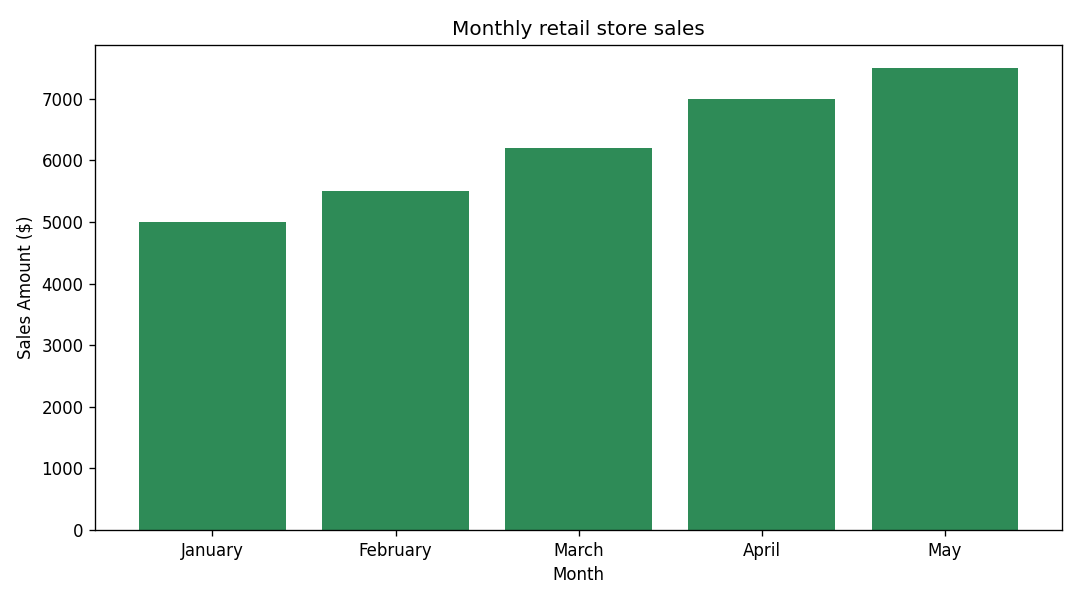

In [3]:
# Compare the five example monthly sales amounts.
months = ["January", "February", "March", "April", "May"]
sales = [5000, 5500, 6200, 7000, 7500]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(months, sales, color="seagreen")

ax.set_title("Monthly retail store sales")
ax.set_xlabel("Month")
ax.set_ylabel("Sales Amount ($)")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Sales increase in each month shown, from $5,000 in January to $7,500 in May. These example values describe only the five displayed months.

**🌟 Preparing the Student Mental Health Dataset**

In [4]:
# Load the survey data used in exercises 4, 5 and 6.
df = pd.read_csv("Student Mental health.csv")
df.columns = df.columns.str.strip()
df = df.rename(columns={"Do you have Panic attack?": "Do you have Panic Attacks?"})

print("Original shape:", df.shape)
display(df.head(5))

Original shape: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic Attacks?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [5]:
# Inspect missing values and clean spaces in categorical responses.
df.info()

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip().replace("", pd.NA)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

print("Missing values:")
print(df.isnull().sum())
display(df["What is your CGPA?"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic Attacks?                    101 non-null    obj

What is your CGPA?
0 - 1.99        4
2.00 - 2.49     2
2.50 - 2.99     4
3.00 - 3.49    43
3.50 - 4.00    48
Name: count, dtype: int64

I remove surrounding spaces so matching CGPA ranges are counted together. The CSV uses `Do you have Panic attack?`; I rename it to `Do you have Panic Attacks?` to match the exercise. Missing values are excluded only from the exercise that needs that field. I do not replace missing ages or responses with invented values.

**🌟 Exercise 4: Visualizing the Distribution of CGPA**

CGPA is already recorded as ranges. I order the ranges from lowest to highest and use the requested `histplot` to show the number of students in each category. These counts do not reveal the exact CGPA values within a range.

Rows excluded for missing CGPA: 0


CGPA category
0 - 1.99        4
2.00 - 2.49     2
2.50 - 2.99     4
3.00 - 3.49    43
3.50 - 4.00    48
Name: count, dtype: int64

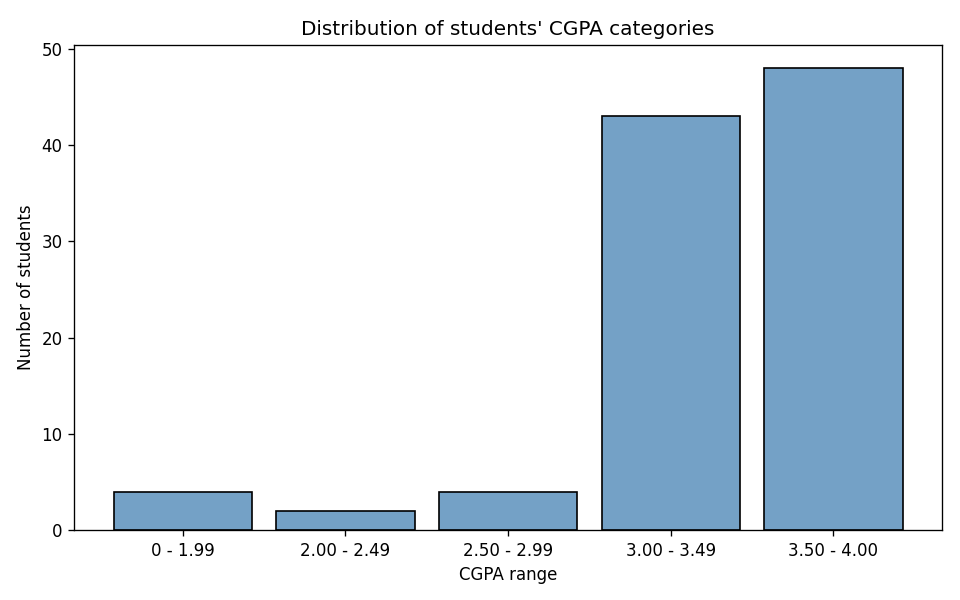

In [6]:
# Order the CGPA ranges and count students in each category.
cgpa_df = df.dropna(subset=["What is your CGPA?"]).copy()
cgpa_order = sorted(cgpa_df["What is your CGPA?"].unique(),
                    key=lambda value: float(value.split("-")[0]))
cgpa_df["CGPA category"] = pd.Categorical(
    cgpa_df["What is your CGPA?"], categories=cgpa_order, ordered=True
)
cgpa_df = cgpa_df.sort_values("CGPA category")
cgpa_counts = cgpa_df["CGPA category"].value_counts(sort=False)

print("Rows excluded for missing CGPA:", len(df) - len(cgpa_df))
display(cgpa_counts)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=cgpa_df, x="CGPA category", discrete=True,
             color="steelblue", shrink=0.85, ax=ax)

ax.set_title("Distribution of students' CGPA categories")
ax.set_xlabel("CGPA range")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.show()

**🌟 Exercise 5: Comparing Anxiety Levels Across Different Genders**

I encode Yes as 1 and No as 0, then calculate the mean within each gender. The mean is the proportion reporting anxiety. This accounts for differences in group size; the chart compares reported anxiety, not its severity.

Rows excluded for missing or unrecognized responses: 0


,count,anxiety_yes,proportion
Choose your gender,,,
Female,75,24,0.320
Male,26,10,0.385


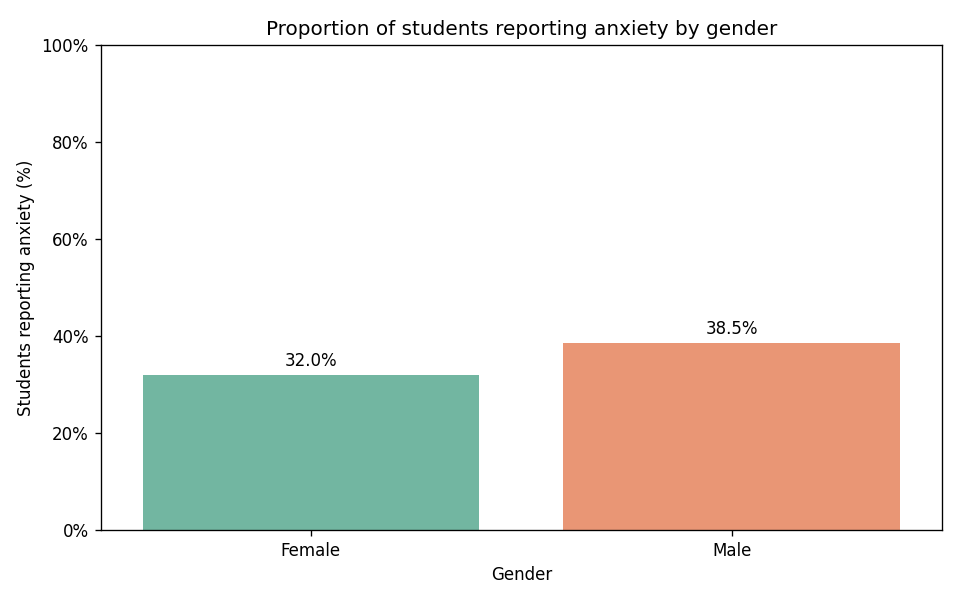

In [7]:
# Calculate the proportion reporting anxiety within each gender.
df["Anxiety numeric"] = df["Do you have Anxiety?"].str.lower().map({"yes": 1, "no": 0})
anxiety_df = df.dropna(subset=["Choose your gender", "Anxiety numeric"]).copy()
anxiety_summary = anxiety_df.groupby("Choose your gender")["Anxiety numeric"].agg(
    count="count", anxiety_yes="sum", proportion="mean"
)

print("Rows excluded for missing or unrecognized responses:", len(df) - len(anxiety_df))
display(anxiety_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=anxiety_summary.reset_index(), x="Choose your gender", y="proportion",
            hue="Choose your gender", palette="Set2", dodge=False,
            errorbar=None, legend=False, ax=ax)

ax.set_title("Proportion of students reporting anxiety by gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Students reporting anxiety (%)")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.1%}" for bar in container], padding=3)
plt.tight_layout()
plt.show()

These percentages describe the survey respondents in each gender group. Group sizes are shown in the table. A difference between the bars does not establish that gender causes anxiety or that the difference applies to all students.

**🌟 Exercise 6: Exploring the Relationship Between Age and Panic Attacks**

I encode panic attack responses as Yes = 1 and No = 0. The scatter plot shows age against this binary response. Small, transparent points help with overlap, but multiple students can still occupy the same position.

Rows excluded for missing age or unrecognized responses: 1


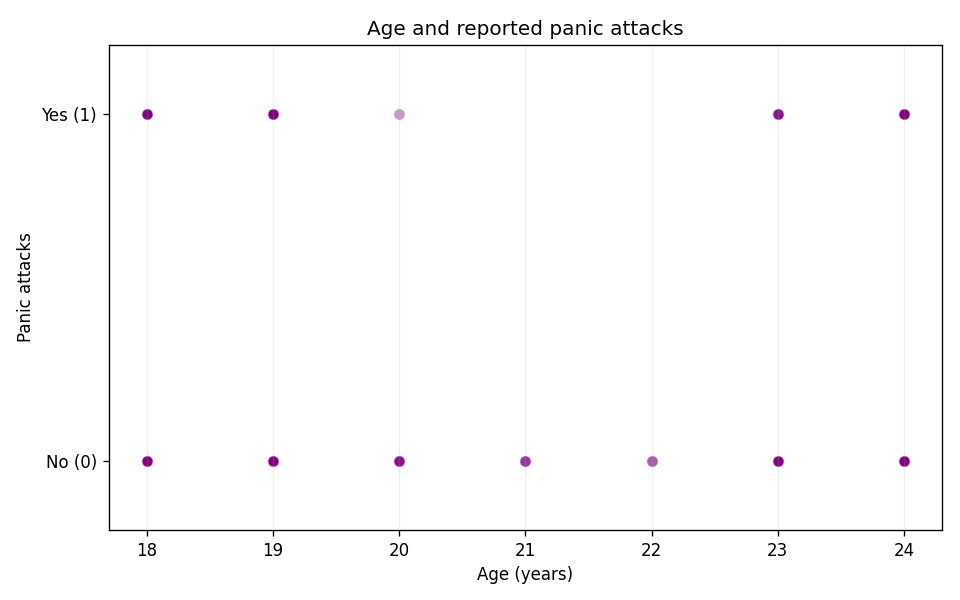

In [8]:
# Encode panic attack responses and keep rows with the required values.
df["Panic attacks numeric"] = df["Do you have Panic Attacks?"].str.lower().map({"yes": 1, "no": 0})
panic_df = df.dropna(subset=["Age", "Panic attacks numeric"]).copy()

print("Rows excluded for missing age or unrecognized responses:", len(df) - len(panic_df))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=panic_df, x="Age", y="Panic attacks numeric",
                color="purple", alpha=0.4, s=45, edgecolor="white", ax=ax)

ax.set_title("Age and reported panic attacks")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Panic attacks")
ax.set_yticks([0, 1], labels=["No (0)", "Yes (1)"])
ax.set_ylim(-0.2, 1.2)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

The two horizontal bands are expected because the response has only two values. The chart shows which ages have Yes or No responses, but overlapping points hide frequencies. I calculate age-group counts and proportions below to support interpretation.

In [9]:
# Show the counts and proportions hidden by overlapping points.
panic_summary = panic_df.groupby("Age")["Panic attacks numeric"].agg(
    count="count", panic_yes="sum", proportion="mean"
)
display(panic_summary.round(3))

,count,panic_yes,proportion
Age,,,
18.0,32,9,0.281
19.0,21,9,0.429
20.0,6,1,0.167
21.0,3,0,0.000
22.0,2,0,0.000
23.0,13,5,0.385
24.0,23,9,0.391


**🌟 Summary of Insights**

In [10]:
# Summarize the calculated results.
print(f"The survey includes {len(df)} records.")
print(f"The most frequent CGPA category is {cgpa_counts.idxmax()} ({cgpa_counts.max()} students).")
for gender, row in anxiety_summary.iterrows():
    print(f"{gender}: {row['proportion']:.1%} report anxiety ({row['anxiety_yes']:.0f} of {row['count']:.0f} responses).")
print(f"The age and panic attack analysis includes {len(panic_df)} complete records.")
print(f"Among those records, {panic_df['Panic attacks numeric'].mean():.1%} report panic attacks.")

The survey includes 101 records.
The most frequent CGPA category is 3.50 - 4.00 (48 students).
Female: 32.0% report anxiety (24 of 75 responses).
Male: 38.5% report anxiety (10 of 26 responses).
The age and panic attack analysis includes 100 complete records.
Among those records, 33.0% report panic attacks.


The line plot shows change over time, the bar charts compare groups, the histogram shows category frequencies, and the scatter plot displays pairs of observations.

The student results are descriptive comparisons for this survey. Small age groups can produce unstable proportions, and the plots do not establish causation or represent all students.